In [1]:
import pandas as pd 
import json
import seaborn as sns
import matplotlib.pyplot as plt

- import data
- rm duplicates
- rm NaN n NULL
- rm unused columns
- year to int

In [2]:
df = pd.read_excel("db/Salmonella-Chile-210824.xlsx")
print(df.shape[0])
df = df.dropna(subset=['cgST', 'Collection Year', 'Source Niche'])
print(df.shape[0])
df = df.drop_duplicates(subset=['cgST', 'Collection Year', 'Source Niche'])
print(df.shape[0])
df = df.drop(columns=['Uberstrain', 'Name', 'Source Niche', 'Source Type',
       'Data Source(Accession No.;Sequencing Platform;Sequencing Library;Insert Size;Experiment;Bases;Average Length;Status)',
       'Barcode', 'Source Details', 'Collection Month', 'Collection Day',
       'Collection Time', 'Continent', 'Country', 'Region', 'District', 'City',
       'Post Code', 'Latitude', 'Longitude', 'Serovar', 'Subspecies',
       'Disease', 'Antigenic Formulas', 'Phage Type', 'Lab Contact', 'Comment',
       'Bio Project ID', 'Project ID', 'Sample ID', 'Secondary Sample ID',
       'Date Entered', 'Release Date', 'SISTR1 Serogroup',
       'SISTR1 H1', 'SISTR1 H2', 'SeqSero2 Serovar', 'SeqSero2 Serogroup',
       'SeqSero2 H1', 'SeqSero2 H2', 'ST', 'eBG', 'Serotype (Predicted)',
       'Lineage', 'Subspecies.1', 'aroC', 'dnaN', 'hemD', 'hisD', 'purE',
       'sucA', 'thrA', 'cgST', 'HC0 (indistinguishable)', 'HC2', 'HC5', 'HC10', 
       'HC100', 'HC200', 'HC400', 'HC900 (ceBG)',
       'HC2000 (Super-lineage)', 'HC2600', 'HC2850 (subsp.)', 'Status',
       'Coverage', 'N50', 'Length', 'Species', 'Contig Number(>=200 bp)',
       'Low Quality Bases', 'Version', 'Assembly Barcode'])
print()
print(df.columns)
df["Collection Year"] = df["Collection Year"].astype(int)
print()
df.head()

2530
2474
1774

Index(['Collection Year', 'SISTR1 Serovar', 'HC20', 'HC50'], dtype='object')



,Collection Year,SISTR1 Serovar,HC20,HC50
0,2006,Typhimurium,305,305
1,2006,Anatum,34548,7
2,2005,Newport,17481,17481
3,2004,Typhimurium,14886,293
4,1945,Typhimurium,17777,1585


### Frequency per year 

### Most frequent serovars

In [3]:
frequent_serovars = ['Enteritidis', 'Typhimurium', 'Infantis', 'Typhi', 'Paratyphi B', 'Sandiego']
df_only_frequent_serovars = df[df['SISTR1 Serovar'].isin(frequent_serovars)]
df_only_frequent_serovars.head()

,Collection Year,SISTR1 Serovar,HC20,HC50
0,2006,Typhimurium,305,305
3,2004,Typhimurium,14886,293
4,1945,Typhimurium,17777,1585
5,2012,Enteritidis,760,87
6,2012,Enteritidis,760,87


### HC20

In [4]:
df_only_frequent_serovars["HC20"] = df_only_frequent_serovars["HC20"].astype(str)
df_only_frequent_serovars['SISTR1 Serovar HC20'] = df_only_frequent_serovars['SISTR1 Serovar'] + " " + df_only_frequent_serovars['HC20']
df_HC20 = df_only_frequent_serovars.drop(columns=['SISTR1 Serovar', 'HC20', 'HC50']).reset_index(drop=True)
df_HC20.head()

/tmp/ipykernel_68090/3388061454.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_only_frequent_serovars["HC20"] = df_only_frequent_serovars["HC20"].astype(str)
/tmp/ipykernel_68090/3388061454.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_only_frequent_serovars['SISTR1 Serovar HC20'] = df_only_frequent_serovars['SISTR1 Serovar'] + " " + df_only_frequent_serovars['HC20']


,Collection Year,SISTR1 Serovar HC20
0,2006,Typhimurium 305
1,2004,Typhimurium 14886
2,1945,Typhimurium 17777
3,2012,Enteritidis 760
4,2012,Enteritidis 760


#### Make json

In [5]:
counts = df_HC20.groupby(['SISTR1 Serovar HC20', 'Collection Year']).size().reset_index(name='Frequency')

db = {}
for _, row in counts.iterrows():
    name = row['SISTR1 Serovar HC20']
    year = row['Collection Year']
    frequency = row['Frequency']
    if name not in db:
        db[name] = {}
    db[name][year] = frequency

#### Export .csv

In [6]:
rows = []
for SISTR1_serovar, year_frequency in db.items():
    year = list(year_frequency.keys())
    min_year = min(year)
    max_year = max(year)
    rows.append([SISTR1_serovar, min_year, max_year])
    
df_for_csv = pd.DataFrame(rows, columns=['SISTR1_serovar', 'start', 'end'])
df_for_csv.to_csv('salmonella_timeline_HC20.csv', index=False)

### Time Line

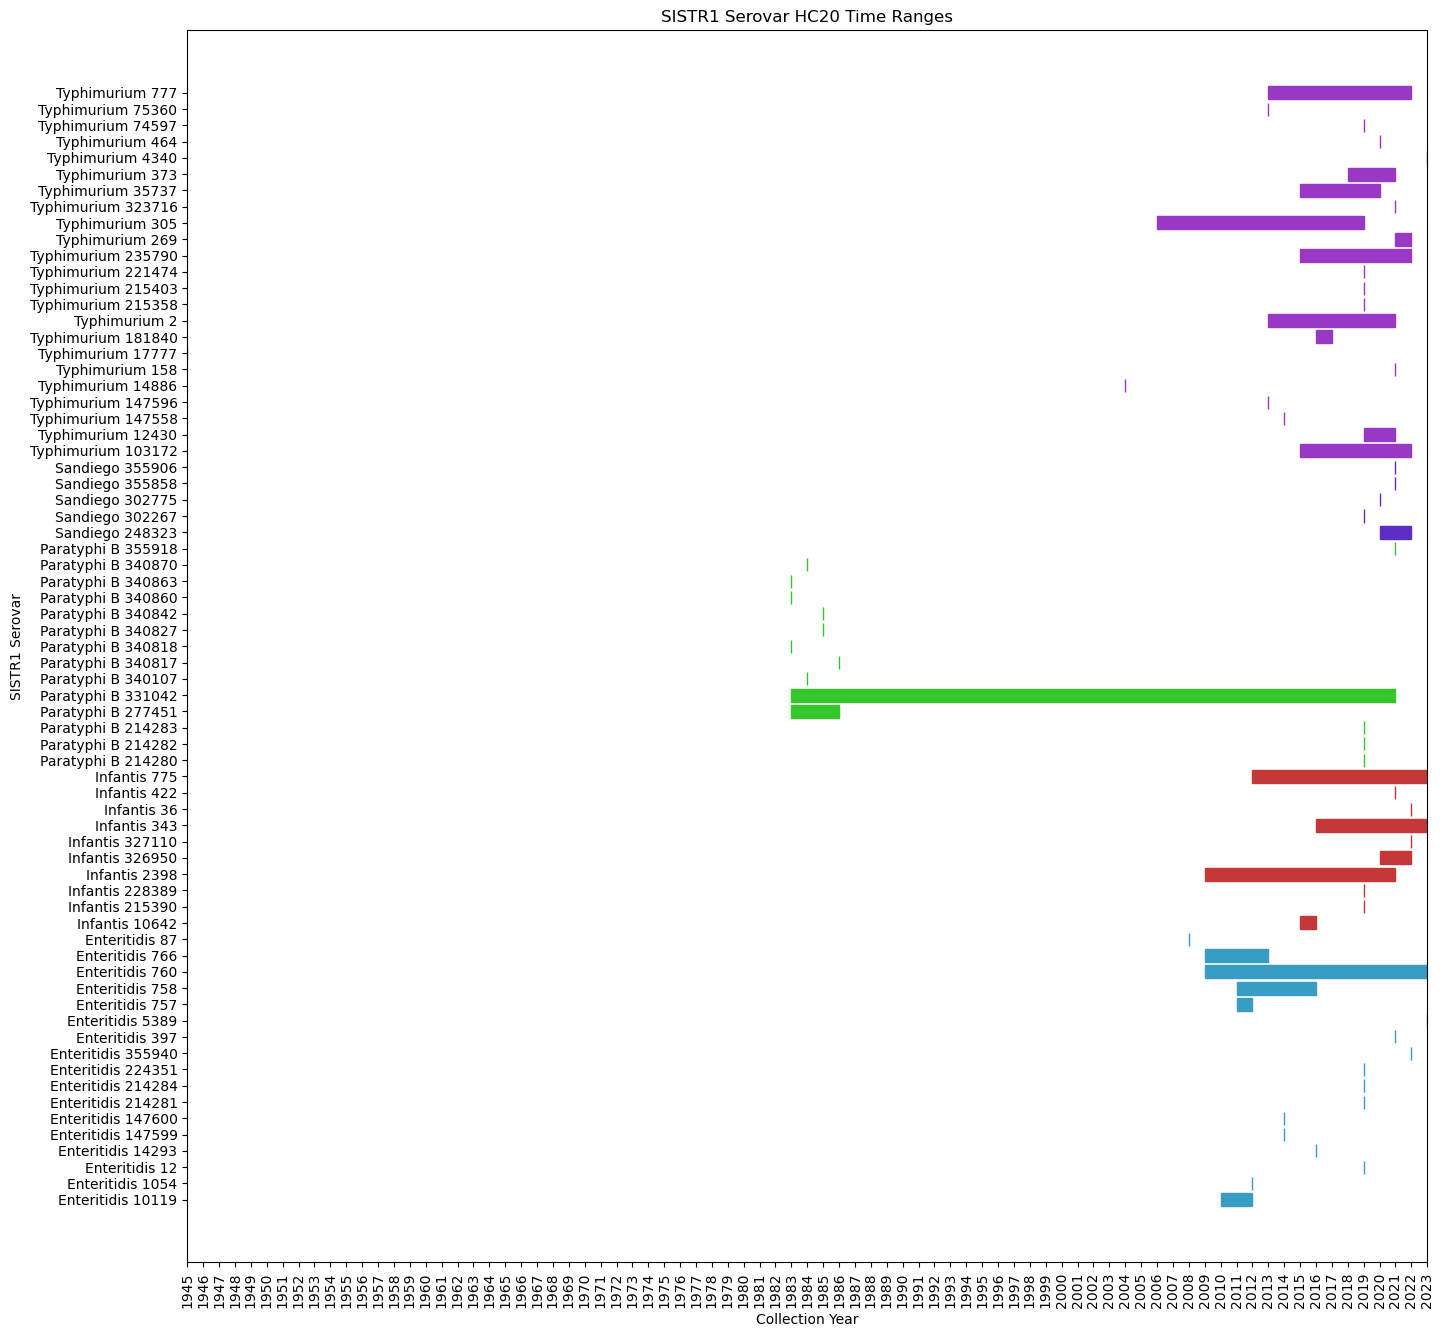

In [9]:
df = pd.read_csv('salmonella_timeline_HC20.csv')

plt.figure(figsize=(16, 16))
for idx, row in df.iterrows():
    if "Typhimurium" in row['SISTR1_serovar']:
        color = "#9838c4"
    elif "Sandiego" in row['SISTR1_serovar']:
        color = '#5e2dc6'
    elif "Paratyphi B" in row['SISTR1_serovar']:
        color = '#35c62d'
    elif "Infantis" in row['SISTR1_serovar']:
        color = '#c43838'
    elif "Enteritidis" in row['SISTR1_serovar']:
        color =  '#389cc4'
    plt.barh(row['SISTR1_serovar'], row['end'] - row['start'], left=row['start'], color=color, edgecolor=color)

plt.title('SISTR1 Serovar HC20 Time Ranges')
plt.xlabel('Collection Year')
plt.ylabel('SISTR1 Serovar')
plt.xticks(ticks=range(df['start'].min(), df['end'].max() + 1), rotation=90)
plt.xlim(df['start'].min(), df['end'].max())

plt.show()

### HC50

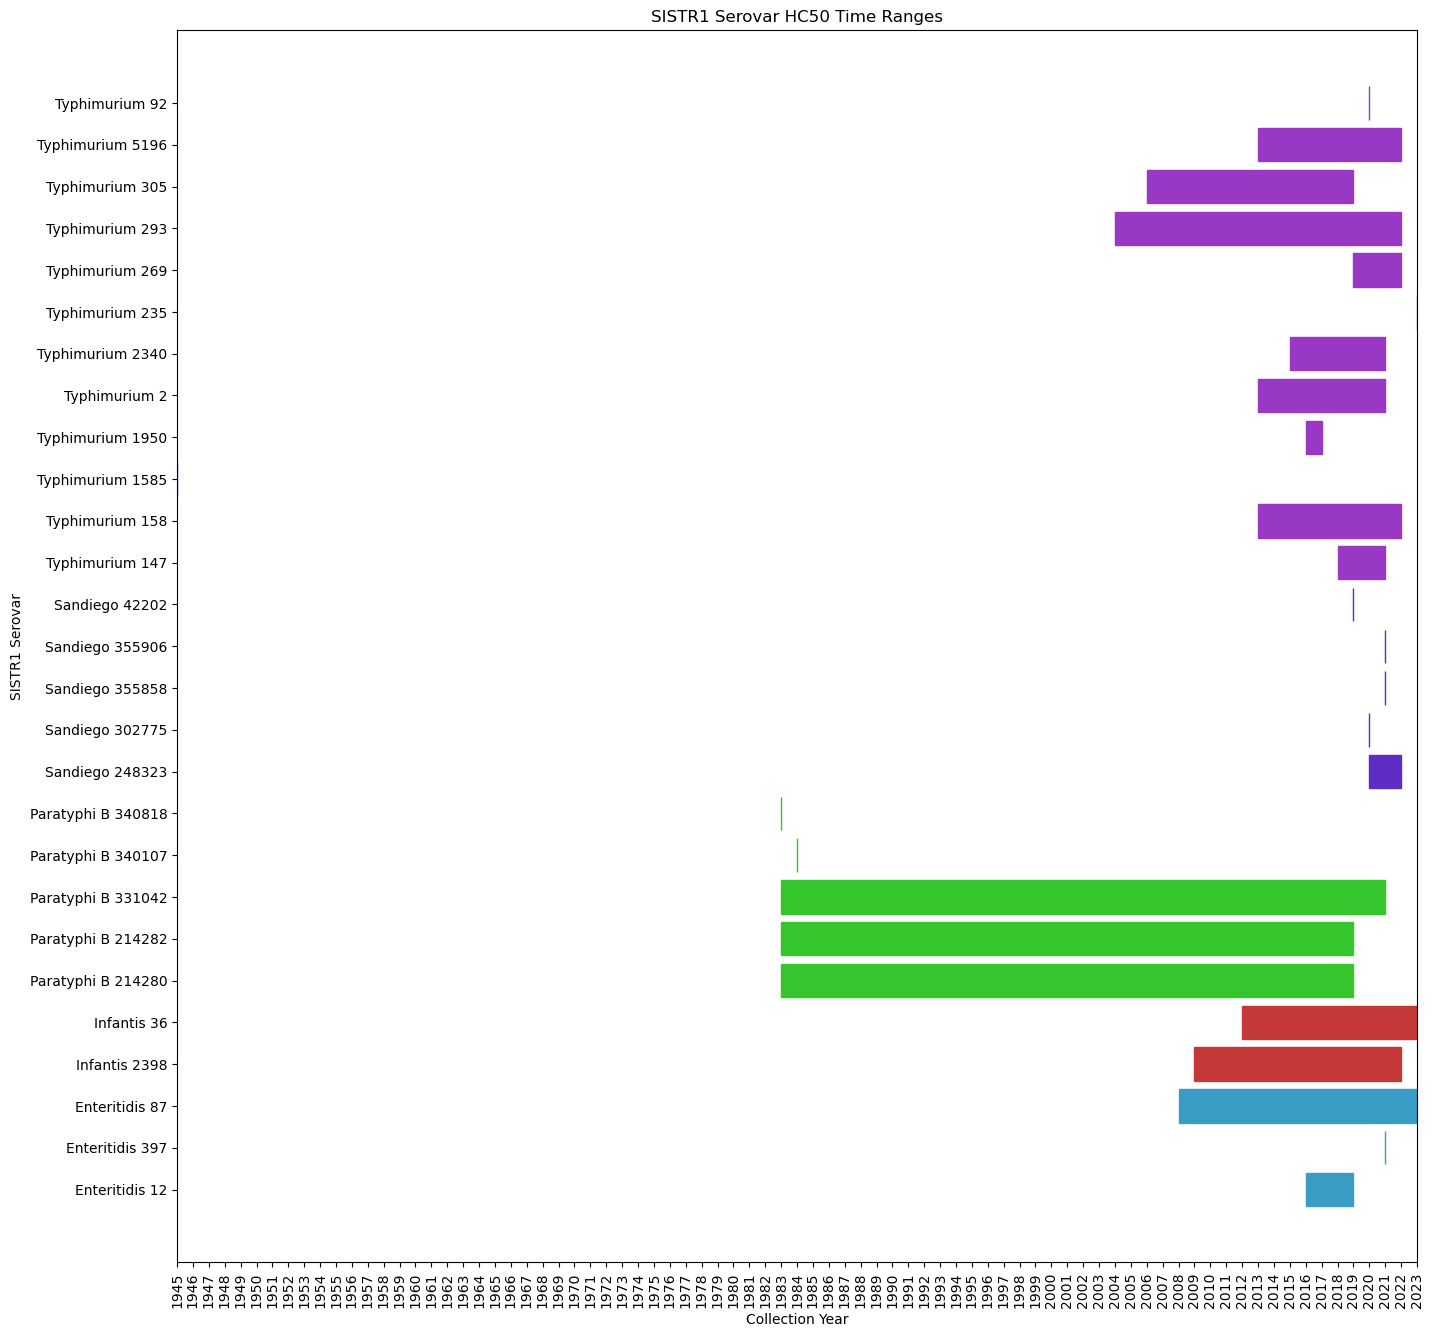

<Figure size 640x480 with 0 Axes>

In [10]:
df_only_frequent_serovars["HC50"] = df_only_frequent_serovars["HC50"].astype(str)
df_only_frequent_serovars['SISTR1 Serovar HC50'] = df_only_frequent_serovars['SISTR1 Serovar'] + " " + df_only_frequent_serovars['HC50']
df_HC50 = df_only_frequent_serovars.drop(columns=['SISTR1 Serovar', 'HC20', 'HC50']).reset_index(drop=True)
df_HC50.head()

counts = df_HC50.groupby(['SISTR1 Serovar HC50', 'Collection Year']).size().reset_index(name='Frequency')

db = {}
for _, row in counts.iterrows():
    name = row['SISTR1 Serovar HC50']
    year = row['Collection Year']
    frequency = row['Frequency']
    if name not in db:
        db[name] = {}
    db[name][year] = frequency

rows = []
for SISTR1_serovar, year_frequency in db.items():
    year = list(year_frequency.keys())
    min_year = min(year)
    max_year = max(year)
    rows.append([SISTR1_serovar, min_year, max_year])
    
df_for_csv = pd.DataFrame(rows, columns=['SISTR1_serovar', 'start', 'end'])
df_for_csv.to_csv('salmonella_timeline_HC50.csv', index=False)

df = pd.read_csv('salmonella_timeline_HC50.csv')

plt.figure(figsize=(16, 16))
for idx, row in df.iterrows():
    if "Typhimurium" in row['SISTR1_serovar']:
        color = "#9838c4"
    elif "Sandiego" in row['SISTR1_serovar']:
        color = '#5e2dc6'
    elif "Paratyphi B" in row['SISTR1_serovar']:
        color = '#35c62d'
    elif "Infantis" in row['SISTR1_serovar']:
        color = '#c43838'
    elif "Enteritidis" in row['SISTR1_serovar']:
        color =  '#389cc4'
    plt.barh(row['SISTR1_serovar'], row['end'] - row['start'], left=row['start'], color=color, edgecolor=color)

plt.title('SISTR1 Serovar HC50 Time Ranges')
plt.xlabel('Collection Year')
plt.ylabel('SISTR1 Serovar')
plt.xticks(ticks=range(df['start'].min(), df['end'].max() + 1), rotation=90)
plt.xlim(df['start'].min(), df['end'].max())

plt.show()
plt.savefig("salmonella_timeline_HC50.png", format='png', dpi=300, bbox_inches='tight')

##### 